## global stuff

### imports

In [155]:
import ast
import re
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle

import os, sys
sys.path.append("/home/user/feature_recombination/")

from kernels import ReluNTK
from feature_decomp import Monomial
from utils import ensure_torch
from misc import rcsetup
from FileManager import FileManager
from ExptTrace import ExptTrace

In [156]:
rcsetup()

In [157]:
colors = ['xkcd:black', 'xkcd:red', 'xkcd:orange yellow', 'xkcd:green', 'xkcd:blue', 'xkcd:purple']
# colors = ['xkcd:black', 'xkcd:lilac', 'xkcd:blue', 'xkcd:green', 'xkcd:orange yellow', 'xkcd:red']
#['xkcd:purple', 'xkcd:raspberry', 'xkcd:cerulean', 'xkcd:tangerine', 'xkcd:black', 'xkcd:forest green', 'xkcd:crimson']
markers = ['x', 's', 'o', '^', 'D', '*', 'v', 'p', 'h']

### plotting

In [158]:
def make_triangle(ax, x=7, y0=5, dlogx=1.3, slope=0.5):
    #triangle        
    dlogy = slope * dlogx 
    x1 = x * 10**dlogx
    y1 = y0 * 10**dlogy
    dx = x1 - x
    dy = y1 - y0
    x_coords = [x, x1, x1]
    y_coords = [y0, y0, y1]
    ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
    ax.plot([x, x1], [y0, y1], 'k-', linewidth=0.5)  
    ax.text(x+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
            va='center', ha='left', fontsize=13, fontweight="light")

In [177]:
from matplotlib.lines import Line2D

def make_color_handles(colors, max_handle=None):
        labels = ["constant", "linear", "quadratic", "cubic", "quartic"]

        # Determine the last included index (inclusive)
        if max_handle is None:
            last = min(len(labels) - 1, len(colors) - 1)
        else:
            if max_handle < 0:
                return []  # nothing to show
            last = min(max_handle, len(labels) - 1, len(colors) - 1)

        pairs = [(lbl, c) for lbl, c in zip(labels[:last+1], colors[:last+1])]

        color_handles = [
            Line2D([0], [0], marker='o', linestyle='none',
                markerfacecolor=c, markeredgecolor='black', markersize=8,
                label=lbl)
            for lbl, c in pairs
        ]
        return color_handles

def add_degree_and_shape_legends(ax, color_handles, colors=colors, legloc = "upper left"):

    # shape_handles = [
    #     Line2D([0], [0], marker=m, linestyle='none',
    #            markerfacecolor='white', markeredgecolor='black', markersize=9,
    #            label=lbl)
    #     for m, lbl in [
    #         ('x', 'constant mode'),
    #         ('s', 'no repeated indices'),
    #         ('o', '1 repeated index'),
    #         ('^', '2 repeated indices'),
    #         ('D', '3 repeated indices'),
    #     ]
    # ]

    # One legend, two columns, top-right
    all_handles = color_handles# + shape_handles
    ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc=legloc,
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        # title="color = degree, shape = index pattern"
    )

In [160]:
import matplotlib.colors as mcolors
# colors = ['xkcd:red', 'xkcd:orange', 'xkcd:gold', 'xkcd:green', 'xkcd:blue', "xkcd:purple", "xkcd:black"]
def lighten(color, amount=0.5):
    rgb = mcolors.to_rgb(mcolors.XKCD_COLORS.get(color, color))
    if amount >= 0:
        new_rgb = tuple(c + (1 - c) * amount for c in rgb)
    else:
        new_rgb = tuple(c * (1 + amount) for c in rgb)
    # Clip values to [0, 1]
    new_rgb = tuple(min(max(x, 0), 1) for x in new_rgb)
    return new_rgb

In [161]:
def plot_ttl_across_max_deg(fig, axes, timekeys_mean, timekeys_std, targets, monomials, eigvals, errorbar_on=True, colors=None, s=6): #fra_eigvals

    target_monomials = targets
    if type(target_monomials[0]) == str:
        target_monomials = np.array([Monomial.from_repr(target_monomial) for target_monomial in target_monomials])
    target_degrees = np.array([target_monomial.degree() for target_monomial in target_monomials])
    target_max_degrees = np.array([target_monomial.max_degree() for target_monomial in target_monomials])
    degrees = np.array([monomial.degree() if monomial in target_monomials else 0 for monomial in monomials], dtype=int)
    max_degrees = np.array([monomial.max_degree() if monomial in target_monomials else 0 for monomial in monomials], dtype=int)


    def _plot_within_order(ax, order=0, opacity=0.5):
        degmaxlocs = torch.tensor(np.where(max_degrees == order)[0])
        degtargetmaxlocs = torch.tensor(np.where(target_max_degrees == order)[0])

        xaxis = (eigvals[degmaxlocs.long()].cpu())**(-1.)
        ys = ensure_torch(timekeys_mean)
        yerr = ensure_torch(timekeys_std)
        slope, intercept = get_log_log_linear_fit(xaxis, ys[degtargetmaxlocs.long()])
        inside_degrees=degrees[degmaxlocs]

        for deg in np.unique(inside_degrees):
            idxs = (inside_degrees == deg)
            if errorbar_on:
                ax.errorbar((eigvals.cpu()[degmaxlocs][idxs])**(-1), timekeys_mean[degtargetmaxlocs][idxs],
                            yerr=yerr[degtargetmaxlocs][idxs],
                            color=colors[deg % len(colors)], alpha=opacity, fmt=markers[order], s=s)
            else:
                ax.scatter((eigvals.cpu()[degmaxlocs][idxs])**(-1), timekeys_mean[degtargetmaxlocs][idxs], marker=markers[order],
                        color=colors[deg % len(colors)], alpha=opacity, s=s)
        ax.set_title(f"Max Degree {order}")
        ax.plot(xaxis, 10**(intercept)*xaxis**(slope), color='k', label=f"log(TTL) = {slope:.2f}*$\\log(\\lambda_{{HEA}}^{{-1}})$+{intercept:.1f}")

    flatax = np.ravel(axes)
    for i, ax in enumerate(flatax, start=1):  # axes[0] -> i=1
        _plot_within_order(ax, order=i)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.legend()

def plot_ttl_across_deg(fig, axes, timekeys_mean, timekeys_std, targets, monomials, eigvals, errorbar_on=True):
    """
    Panels are grouped by *degree >= 1*. The degree-1 panel also overlays degree-0 points.
    Marker encodes max_degree; color encodes the degree whose panel you're in.
    Only the fitted line appears in the legend (no scatter/errorbar entries).
    """
    # Normalize targets -> Monomial objects
    target_monomials = targets
    if isinstance(target_monomials[0], str):
        target_monomials = np.array([Monomial.from_repr(t) for t in target_monomials])
    else:
        target_monomials = np.array(target_monomials)

    # Degrees/max-degrees for targets (index space of timekeys_* arrays)
    target_degrees      = np.array([m.degree()      for m in target_monomials], dtype=int)
    target_max_degrees  = np.array([m.max_degree()  for m in target_monomials], dtype=int)

    # Degrees/max-degrees aligned to full 'monomials' list; 0 for non-targets
    degrees     = np.array([m.degree()     if m in target_monomials else 0 for m in monomials], dtype=int)
    max_degrees = np.array([m.max_degree() if m in target_monomials else 0 for m in monomials], dtype=int)

    def _plot_degree(ax, deg, opacity=0.5, overlay_deg0=False):
        # --- Main (deg) data ---
        deglocs       = torch.tensor(np.where(degrees == deg)[0])                  # monomials/eigvals indices
        degtargetlocs = torch.tensor(np.where(target_degrees == deg)[0])           # targets/timekeys indices

        if deglocs.numel() == 0 or degtargetlocs.numel() == 0:
            ax.set_title(f"Degree {deg} (no data)")
            return

        xaxis = (eigvals[deglocs.long()].cpu())**(-1.0)
        ys    = ensure_torch(timekeys_mean)[degtargetlocs.long()]
        yerr  = ensure_torch(timekeys_std)[degtargetlocs.long()]

        n = min(len(xaxis), len(ys))
        xaxis, ys, yerr = xaxis[:n], ys[:n], yerr[:n]

        slope, intercept = get_log_log_linear_fit_positive(xaxis, ys)

        # Scatter/errorbar by max_degree (no legend labels)
        inside_max_degrees = max_degrees[deglocs][:n]
        for mdeg in np.unique(inside_max_degrees):
            mask = (inside_max_degrees == mdeg)
            if not np.any(mask):
                continue
            marker = markers[mdeg % len(markers)]
            if errorbar_on:
                ax.errorbar(xaxis[mask], ys[mask], yerr=yerr[mask],
                            color=colors[deg % len(colors)], alpha=opacity, fmt=marker, label="_nolegend_")
            else:
                ax.scatter(xaxis[mask], ys[mask], alpha=opacity, marker=marker,
                           color=colors[deg % len(colors)], label="_nolegend_")

        # Optional: overlay degree 0 points on the degree 1 panel (no legend; does not affect fit)
        if overlay_deg0:
            d0locs       = torch.tensor(np.where(degrees == 0)[0])
            d0targetlocs = torch.tensor(np.where(target_degrees == 0)[0])
            if d0locs.numel() > 0 and d0targetlocs.numel() > 0:
                x0 = (eigvals[d0locs.long()].cpu())**(-1.0)
                y0 = ensure_torch(timekeys_mean)[d0targetlocs.long()]
                e0 = ensure_torch(timekeys_std)[d0targetlocs.long()]
                m0 = min(len(x0), len(y0))
                x0, y0, e0 = x0[:m0], y0[:m0], e0[:m0]
                # Use a distinct, faint look; still no legend entry
                if errorbar_on:
                    ax.errorbar(x0, y0, yerr=e0, fmt=markers[0 % len(markers)],
                                alpha=0.35, color=colors[0 % len(colors)], label="_nolegend_")
                else:
                    ax.scatter(x0, y0, marker=markers[0 % len(markers)],
                               alpha=0.35, color=colors[0 % len(colors)], label="_nolegend_")

        # Only the regression line gets a legend label
        (line_handle,) = ax.plot(xaxis, (10.0**intercept) * (xaxis**slope), color='k',
                                 label=f"log(TTL) = {slope:.2f}·$\\log(\\lambda_{{HEA}}^{{-1}})$ + {intercept:.1f}")
        ax.set_title(f"Degree {deg}")
        ax.set_xscale('log')
        ax.set_yscale('log')
        # Legend shows only the line because all scatters had label "_nolegend_"
        ax.legend(handles=[line_handle])

    # Panels: start at degree = 1 (no separate degree-0 panel)
    flatax = np.ravel(axes)
    for i, ax in enumerate(flatax, start=1):  # axes[0] -> degree 1, axes[1] -> degree 2, ...
        overlay = (i == 1)  # overlay deg 0 only on degree 1 panel
        _plot_degree(ax, deg=i, overlay_deg0=overlay)


def get_log_log_linear_fit(x, y, fixed_slope: float | None = None):
    """
    Fit log10(y) = slope * log10(x) + intercept.
    If fixed_slope is provided, only estimate the intercept.
    """
    xt = ensure_torch(x)
    yt = ensure_torch(y)

    log_x = torch.log10(xt).reshape(-1, 1)
    z = torch.log10(yt).reshape(-1, 1)

    if fixed_slope is not None:
        m = float(fixed_slope)
        b = float((z - m * log_x).mean())
        return m, b

    A = torch.column_stack((log_x, torch.ones_like(log_x)))
    sol = torch.linalg.lstsq(A, z).solution.squeeze()  # [slope, intercept]
    return float(sol[0]), float(sol[1])

In [162]:
def plot_time_to_learn_eigenvalue(eigvals, timekeys, target_monomials, scale='log', **kwargs):
    target_monomials = np.asarray(target_monomials, dtype=object)
    if target_monomials.size == 0:
        return
    if type(target_monomials[0]) == str:
        target_monomials = np.array([Monomial.from_repr(target_monomial) for target_monomial in target_monomials])
    degrees = np.array([target_monomial.degree() for target_monomial in target_monomials])
    colors = kwargs.get("colors", ['xkcd:red', 'xkcd:orange', 'xkcd:gold', 'xkcd:green', 'xkcd:blue', "xkcd:purple", "xkcd:black"])
    #marker stuff
    markers = ['x', 's', 'o', '^', 'D', '*', 'v', 'p', 'h']
    max_degrees  = np.array([target_monomial.max_degree() for target_monomial in target_monomials])
    max_deg = int(np.asarray(max_degrees).max())
    uniq_md = np.arange(max_deg + 1)
    md2marker   = {md: markers[i % len(markers)] for i, md in enumerate(uniq_md)}

    pairs = np.unique(np.stack([degrees, max_degrees], axis=1), axis=0)

    for degree, md in pairs:
        idxs = np.flatnonzero((degrees == degree) & (max_degrees == md))
        if kwargs.get("errorbar", False):
            plt.errorbar((eigvals[idxs])**(-1), timekeys[idxs], yerr=kwargs.get("yerr")[idxs], color=colors[degree % len(colors)], alpha=kwargs.get("alpha", 1), fmt=md2marker[md])
        else:
            plt.scatter((eigvals[idxs])**(-1), timekeys[idxs], marker=md2marker[md], color=colors[degree % len(colors)], alpha=kwargs.get("alpha", 1))
    plt.xscale(scale)
    plt.yscale(scale)
    plt.xlabel(f"HEA Eigval $\\lambda^{{-1}}$")
    plt.ylabel(f"Time to learn "+kwargs.get("breakpoint", ""))
    # plt.title(f"Time to learn vs FRA Eigval")

def plot_time_to_learn_eigenvalue_lightened(eigvals, timekeys, target_monomials, scale='log', lightenamount=0, **kwargs):
    target_monomials = np.asarray(target_monomials, dtype=object)
    if target_monomials.size == 0:
        return
    if type(target_monomials[0]) == str:
        target_monomials = np.array([Monomial.from_repr(target_monomial) for target_monomial in target_monomials])
    degrees = np.array([target_monomial.degree() for target_monomial in target_monomials])
    colors = kwargs.get("colors", ['xkcd:red', 'xkcd:orange', 'xkcd:gold', 'xkcd:green', 'xkcd:blue', "xkcd:purple", "xkcd:black"])
    #marker stuff
    markers = ['x', 's', 'o', '^', 'D', '*', 'v', 'p', 'h']
    max_degrees  = np.array([target_monomial.max_degree() for target_monomial in target_monomials])
    max_deg = int(np.asarray(max_degrees).max())
    uniq_md = np.arange(max_deg + 1)
    md2marker   = {md: markers[i % len(markers)] for i, md in enumerate(uniq_md)}

    pairs = np.unique(np.stack([degrees, max_degrees], axis=1), axis=0)

    for degree, md in pairs:
        idxs = np.flatnonzero((degrees == degree) & (max_degrees == md))
        if kwargs.get("errorbar", False):
            plt.errorbar((eigvals[idxs])**(-1), timekeys[idxs], yerr=kwargs.get("yerr")[idxs], color=lighten(colors[degree % len(colors)], amount=lightenamount), alpha=kwargs.get("alpha", 1), fmt=md2marker[md])
        else:
            plt.scatter((eigvals[idxs])**(-1), timekeys[idxs], marker=md2marker[md], color=lighten(colors[degree % len(colors)], amount=lightenamount), alpha=kwargs.get("alpha", 1))
    plt.xscale(scale)
    plt.yscale(scale)
    # plt.title(f"Time to learn vs FRA Eigval")

def plot_time_to_learn_eigenvalue_lightened_ax(ax, eigvals, timekeys, target_monomials, scale='log', lightenamount=0, **kwargs):
    target_monomials = np.asarray(target_monomials, dtype=object)
    if target_monomials.size == 0:
        return
    if type(target_monomials[0]) == str:
        target_monomials = np.array([Monomial.from_repr(target_monomial) for target_monomial in target_monomials])
    degrees = np.array([target_monomial.degree() for target_monomial in target_monomials])
    colors = kwargs.get("colors", ['xkcd:red', 'xkcd:orange', 'xkcd:gold', 'xkcd:green', 'xkcd:blue', "xkcd:purple", "xkcd:black"])
    #marker stuff
    markers = ['x', 's', 'o', '^', 'D', '*', 'v', 'p', 'h']
    max_degrees  = np.array([target_monomial.max_degree() for target_monomial in target_monomials])
    max_deg = int(np.asarray(max_degrees).max())
    uniq_md = np.arange(max_deg + 1)
    md2marker   = {md: markers[i % len(markers)] for i, md in enumerate(uniq_md)}

    pairs = np.unique(np.stack([degrees, max_degrees], axis=1), axis=0)

    for degree, md in pairs:
        idxs = np.flatnonzero((degrees == degree) & (max_degrees == md))
        if kwargs.get("errorbar", False):#fmt=md2marker[md]
            ax.errorbar((eigvals[idxs])**(-1), timekeys[idxs], yerr=kwargs.get("yerr")[idxs], color=lighten(colors[degree % len(colors)], amount=lightenamount),
                        alpha=kwargs.get("alpha", 1), fmt=markers[kwargs.get('marker_index', 2)], ms=kwargs.get("s"))
        else:#md2marker[md]
            ax.scatter((eigvals[idxs])**(-1), timekeys[idxs], color=lighten(colors[degree % len(colors)], amount=lightenamount),
                       alpha=kwargs.get("alpha", 1), marker=markers[kwargs.get('marker_index', 2)], ms=kwargs.get("s"))
    ax.set_xscale(scale)
    ax.set_yscale(scale)
    # plt.title(f"Time to learn vs FRA Eigval")

def plot_time_to_learn_eigenvalue_ax(ax, eigvals, timekeys, target_monomials, scale='log', **kwargs):
    target_monomials = np.asarray(target_monomials, dtype=object)
    if target_monomials.size == 0:
        return
    if type(target_monomials[0]) == str:
        target_monomials = np.array([Monomial.from_repr(target_monomial) for target_monomial in target_monomials])
    degrees = np.array([target_monomial.degree() for target_monomial in target_monomials])
    colors = kwargs.get("colors", ['xkcd:red', 'xkcd:orange', 'xkcd:gold', 'xkcd:green', 'xkcd:blue', "xkcd:purple", "xkcd:black"])
    #marker stuff
    markers = ['x', 's', 'o', '^', 'D', '*', 'v', 'p', 'h']
    max_degrees  = np.array([target_monomial.max_degree() for target_monomial in target_monomials])
    max_deg = int(np.asarray(max_degrees).max())
    uniq_md = np.arange(max_deg + 1)
    md2marker   = {md: markers[i % len(markers)] for i, md in enumerate(uniq_md)}

    pairs = np.unique(np.stack([degrees, max_degrees], axis=1), axis=0)

    for degree, md in pairs:
        idxs = np.flatnonzero((degrees == degree) & (max_degrees == md))
        if kwargs.get("errorbar", False):
            ax.errorbar((eigvals[idxs])**(-1), timekeys[idxs], yerr=kwargs.get("yerr")[idxs], color=colors[degree % len(colors)], alpha=kwargs.get("alpha", 1), fmt=md2marker[md])
        else:
            ax.scatter((eigvals[idxs])**(-1), timekeys[idxs], marker=md2marker[md], color=colors[degree % len(colors)], alpha=kwargs.get("alpha", 1))
    ax.set_xscale(scale)
    ax.set_yscale(scale)
    # plt.title(f"Time to learn vs FRA Eigval")

def plot_time_to_learn_eigenvalue_ax(ax, eigvals, timekeys, target_monomials, scale='log', **kwargs):
    target_monomials = np.asarray(target_monomials, dtype=object)
    if target_monomials.size == 0:
        return
    if type(target_monomials[0]) == str:
        target_monomials = np.array([Monomial.from_repr(target_monomial) for target_monomial in target_monomials])
    degrees = np.array([target_monomial.degree() for target_monomial in target_monomials])
    colors = kwargs.get("colors", ['xkcd:red', 'xkcd:orange', 'xkcd:gold', 'xkcd:green', 'xkcd:blue', "xkcd:purple", "xkcd:black"])
    #marker stuff
    markers = ['x', 's', 'o', '^', 'D', '*', 'v', 'p', 'h']
    max_degrees  = np.array([target_monomial.max_degree() for target_monomial in target_monomials])
    max_deg = int(np.asarray(max_degrees).max())
    uniq_md = np.arange(max_deg + 1)
    md2marker   = {md: markers[i % len(markers)] for i, md in enumerate(uniq_md)}

    pairs = np.unique(np.stack([degrees, max_degrees], axis=1), axis=0)

    for degree, md in pairs:
        idxs = np.flatnonzero((degrees == degree) & (max_degrees == md))
        if kwargs.get("errorbar", False):
            ax.errorbar((eigvals[idxs])**(-1), timekeys[idxs], yerr=kwargs.get("yerr")[idxs], color=colors[degree % len(colors)], alpha=kwargs.get("alpha", 1), fmt=md2marker[md])
        else:
            ax.scatter((eigvals[idxs])**(-1), timekeys[idxs], marker=md2marker[md], color=colors[degree % len(colors)], alpha=kwargs.get("alpha", 1))
    ax.set_xscale(scale)
    ax.set_yscale(scale)
    # plt.title(f"Time to learn vs FRA Eigval")

### load results grabbing

In [163]:
def _load_result(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def _threshold_index(loss_checkpoints, ttl_threshold):
    thresholds = np.asarray(loss_checkpoints, dtype=float)
    thresholds = np.sort(thresholds)[::-1]
    idx = int(np.argmin(np.abs(thresholds - ttl_threshold)))
    if not np.isclose(thresholds[idx], ttl_threshold, rtol=1e-6, atol=1e-9):
        raise ValueError(f"ttl_threshold={ttl_threshold} not found in loss_checkpoints={thresholds.tolist()}")
    return idx, thresholds

def _coerce_monomial(value):
    if isinstance(value, Monomial):
        return value.copy()
    if isinstance(value, dict):
        return Monomial({int(k): int(v) for k, v in value.items()})
    if isinstance(value, str):
        text = value.strip()
        try:
            parsed = ast.literal_eval(text)
        except Exception:
            parsed = None
        if isinstance(parsed, dict):
            return Monomial({int(k): int(v) for k, v in parsed.items()})
        return Monomial.from_repr(text)
    raise TypeError(f"Unsupported monomial value: {type(value)!r}")


def _build_plot_compat(result, targets, monomials, hea_eigvals, eff_times, eff_stds, lr):
    target_info = result.setdefault("target_info", {})
    target_info["monomials"] = [m.copy() for m in monomials]

    pseudo_timekeys = np.asarray(eff_times, dtype=float)
    if lr != 0:
        pseudo_timekeys = pseudo_timekeys / lr
    pseudo_timekeys = pseudo_timekeys.reshape(1, -1, 1)

    return {
        "timekeys": pseudo_timekeys,
        "targets": np.asarray(targets, dtype=object),
        "num_trials": pseudo_timekeys.shape[-1],
        "monomials": np.asarray(monomials, dtype=object),
        "hea_eigvals": torch.as_tensor(np.asarray(hea_eigvals, dtype=float)),
        "breakpoints_means": torch.as_tensor(np.asarray(eff_times, dtype=float)),
        "breakpoints_std": torch.as_tensor(np.asarray(eff_stds, dtype=float)),
    }


def _extract_times(result, ttl_threshold, lr_override=None):
    timekeys = result["timekeys"]["config2outcome"]
    losses = result["losses"]["config2outcome"]

    loss_checkpoints = result.get("loss_checkpoints", [ttl_threshold])
    ttl_idx, _ = _threshold_index(loss_checkpoints, ttl_threshold)

    training_cfg = result.get("training_config", {})
    lr = float(lr_override) if lr_override is not None else float(training_cfg.get("LR", 1.0))

    target_info = result.get("target_info", {})
    target_map = target_info.get("monomial_str_to_eigval") or result.get("target_map") or {}
    bases = target_info.get("monomials") or target_info.get("monomial_bases") or []
    monomial_strs = target_info.get("monomial_strs") or []
    stored_eigs = target_info.get("hea_eigvals") or []

    monomial_lookup = {}
    eig_lookup = {}
    order_lookup = {}

    for idx, basis in enumerate(bases):
        monomial = _coerce_monomial(basis)
        eigval = float(stored_eigs[idx]) if idx < len(stored_eigs) else None
        keys = {str(basis), str(monomial)}
        if idx < len(monomial_strs):
            keys.add(str(monomial_strs[idx]))
        for key in keys:
            monomial_lookup[key] = monomial
            if eigval is not None:
                eig_lookup[key] = eigval
            order_lookup[key] = monomial.degree()

    for key, eigval in target_map.items():
        try:
            monomial = _coerce_monomial(key)
        except Exception:
            continue
        monomial_lookup.setdefault(key, monomial)
        monomial_lookup.setdefault(str(monomial), monomial)
        eig_lookup[key] = float(eigval)
        eig_lookup.setdefault(str(monomial), float(eigval))
        order_lookup.setdefault(key, monomial.degree())
        order_lookup.setdefault(str(monomial), monomial.degree())

    if not eig_lookup:
        raise ValueError("No monomial-to-eigenvalue mapping found in result.")

    # Aggregate steps by monomial across trials
    monomial_steps = {}
    for config, tk in timekeys.items():
        raw_monomial = config[-1]
        try:
            monomial = monomial_lookup.get(raw_monomial, _coerce_monomial(raw_monomial))
        except Exception:
            monomial = None
        if monomial is None:
            continue
        monomial_key = str(monomial)
        tk_arr = np.asarray(tk)
        if tk_arr.ndim == 0:
            step_idx = int(tk_arr)
        else:
            step_idx = int(tk_arr[ttl_idx])

        # Ignore trials that never crossed the threshold (timekey==0)
        if step_idx == 0:
            continue

        final_loss = losses.get(config, None)
        if final_loss is not None:
            final_loss_val = float(np.asarray(final_loss))
            if final_loss_val > ttl_threshold:
                continue  # threshold not reached

        # Convert step index -> number of gradient steps executed
        steps = step_idx + 1
        monomial_steps.setdefault(monomial_key, []).append(steps)

    inv_eigs = []
    eff_times = []
    eff_stds = []
    orders = []
    filtered_targets = []
    filtered_monomials = []
    filtered_hea_eigvals = []
    for monomial_key, steps_list in monomial_steps.items():
        monomial = monomial_lookup.get(monomial_key, _coerce_monomial(monomial_key))
        eigval = eig_lookup.get(monomial_key)
        if eigval is None:
            eigval = eig_lookup.get(str(monomial))
        order = order_lookup.get(monomial_key, monomial.degree())
        if eigval is None or eigval <= 0:
            continue
        inv_eigs.append(1.0 / eigval)
        eff_times.append(lr * float(np.mean(steps_list)))
        eff_stds.append(lr * float(np.std(steps_list, ddof=0)))
        orders.append(order)
        filtered_targets.append(str(monomial))
        filtered_monomials.append(monomial)
        filtered_hea_eigvals.append(eigval)

    compat = _build_plot_compat(
        result,
        targets=filtered_targets,
        monomials=filtered_monomials,
        hea_eigvals=filtered_hea_eigvals,
        eff_times=eff_times,
        eff_stds=eff_stds,
        lr=lr,
    )
    return np.asarray(inv_eigs), np.asarray(eff_times), np.asarray(eff_stds), np.asarray(orders), lr, compat

## all results

### base

In [164]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/synthetic'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_base = _load_result(result_path)

ttl_threshold = float(result_base.get("ttl_threshold", 0.1))

inv_eigs_base, eff_times_base, eff_stds_base, orders_base, lr_base, compat_base = _extract_times(result_base, ttl_threshold)

### width

In [165]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/synthetic_low_width'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_low_width = _load_result(result_path)

ttl_threshold = float(result_low_width.get("ttl_threshold", 0.1))

inv_eigs_low_width, eff_times_low_width, eff_stds_low_width, orders_low_width, lr_low_width, compat_low_width = _extract_times(result_low_width, ttl_threshold)

### depth

In [166]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/synthetic_low_depth'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_low_depth = _load_result(result_path)

ttl_threshold = float(result_low_depth.get("ttl_threshold", 0.1))

inv_eigs_low_depth, eff_times_low_depth, eff_stds_low_depth, orders_low_depth, lr_low_depth, compat_low_depth = _extract_times(result_low_depth, ttl_threshold)

### lr

In [167]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/synthetic_high_lr'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_high_lr = _load_result(result_path)

ttl_threshold = float(result_high_lr.get("ttl_threshold", 0.1))

inv_eigs_high_lr, eff_times_high_lr, eff_stds_high_lr, orders_high_lr, lr_high_lr, compat_high_lr = _extract_times(result_high_lr, ttl_threshold)

### NTK

In [168]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/synthetic_lazy'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_lazy = _load_result(result_path)

ttl_threshold = float(result_lazy.get("ttl_threshold", 0.1))

inv_eigs_lazy, eff_times_lazy, eff_stds_lazy, orders_lazy, lr_lazy, compat_lazy = _extract_times(result_lazy, ttl_threshold)
lr_lazy = 2e-1

### hyper-rich

In [169]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/synthetic_ultra_rich'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_ultra_rich = _load_result(result_path)

ttl_threshold = float(result_ultra_rich.get("ttl_threshold", 0.1))

inv_eigs_ultra_rich, eff_times_ultra_rich, eff_stds_ultra_rich, orders_ultra_rich, lr_ultra_rich, compat_ultra_rich = _extract_times(result_ultra_rich, ttl_threshold)

### bsz

In [170]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/synthetic_low_bsz'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_low_bsz = _load_result(result_path)

ttl_threshold = float(result_low_bsz.get("ttl_threshold", 0.1))

inv_eigs_low_bsz, eff_times_low_bsz, eff_stds_low_bsz, orders_low_bsz, lr_low_bsz, compat_low_bsz = _extract_times(result_low_bsz, ttl_threshold)

### data exponent

In [171]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/synthetic_low_data_exponent'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_low_data_exponent = _load_result(result_path)

ttl_threshold = float(result_low_data_exponent.get("ttl_threshold", 0.1))

inv_eigs_low_data_exponent, eff_times_low_data_exponent, eff_stds_low_data_exponent, orders_low_data_exponent, lr_low_data_exponent, compat_low_data_exponent = _extract_times(result_low_data_exponent, ttl_threshold)

### cifar

In [172]:
dataset_path = '/mnt/private/results/hermite-eigenstructure-ansatz/mlp/cifar5m'
result_path = os.path.join(dataset_path, "result_ttl.pickle")
result_cifar = _load_result(result_path)

ttl_threshold = float(result_cifar.get("ttl_threshold", 0.1))

inv_eigs_cifar, eff_times_cifar, eff_stds_cifar, orders_cifar, lr_cifar, compat_cifar = _extract_times(result_cifar, ttl_threshold)

## base case

In [150]:
timekeys_base = compat_base["timekeys"]
targets_base = compat_base["targets"]
num_trials_base = compat_base["num_trials"]
monomials_base = compat_base["monomials"]
hea_eigvals_base = compat_base["hea_eigvals"]
locs_base = torch.zeros(len(targets_base))

for i, monomial in enumerate(targets_base):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_base):
        break
    # print(loc)
    loc = np.where(np.array(monomials_base) == monomial)[0][0]
    locs_base[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_base))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_base):
        break
    if monomial in monomials_base:
        loc = np.where(np.array(monomials_base) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc

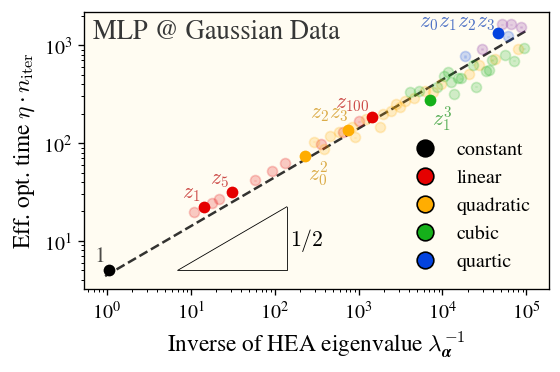

In [151]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
breakpoints_means = compat_base["breakpoints_means"]
breakpoints_std = compat_base["breakpoints_std"]

xaxis = ((hea_eigvals_base[locs_base.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_base[locs_base.long()].cpu(), breakpoints_means.cpu(), targets_base,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_base.min()) * 0.9
x_max = float(inv_eigs_base.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.65)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_base[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_base[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_base[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()


## depth

In [96]:
timekeys_low_depth = compat_low_depth["timekeys"]
targets_low_depth = compat_low_depth["targets"]
num_trials_low_depth = compat_low_depth["num_trials"]
monomials_low_depth = compat_low_depth["monomials"]
hea_eigvals_low_depth = compat_low_depth["hea_eigvals"]
locs_low_depth = torch.zeros(len(targets_low_depth))

for i, monomial in enumerate(targets_low_depth):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_low_depth):
        break
    # print(loc)
    loc = np.where(np.array(monomials_low_depth) == monomial)[0][0]
    locs_low_depth[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_low_depth))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_low_depth):
        break
    if monomial in monomials_low_depth:
        loc = np.where(np.array(monomials_low_depth) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc

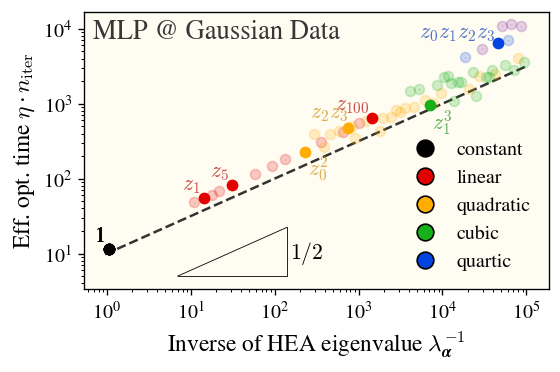

In [97]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
breakpoints_means = compat_low_depth["breakpoints_means"]
breakpoints_std = compat_low_depth["breakpoints_std"]

xaxis = ((hea_eigvals_low_depth[locs_low_depth.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_low_depth[locs_low_depth.long()].cpu(), breakpoints_means.cpu(), targets_low_depth,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_low_depth.min()) * 0.9
x_max = float(inv_eigs_low_depth.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(1.0)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_low_depth[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_low_depth[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_low_depth[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()


## lr
under def of TTK, intercept unaffected

In [98]:
timekeys_high_lr = compat_high_lr["timekeys"]
targets_high_lr = compat_high_lr["targets"]
num_trials_high_lr = compat_high_lr["num_trials"]
monomials_high_lr = compat_high_lr["monomials"]
hea_eigvals_high_lr = compat_high_lr["hea_eigvals"]
locs_high_lr = torch.zeros(len(targets_high_lr))

for i, monomial in enumerate(targets_high_lr):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_high_lr):
        break
    # print(loc)
    loc = np.where(np.array(monomials_high_lr) == monomial)[0][0]
    locs_high_lr[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_high_lr))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_high_lr):
        break
    if monomial in monomials_high_lr:
        loc = np.where(np.array(monomials_high_lr) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc

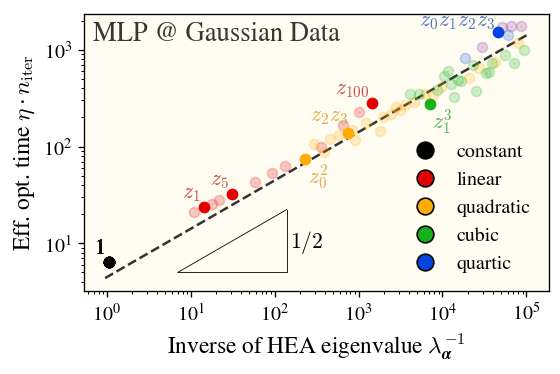

In [99]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
breakpoints_means = compat_high_lr["breakpoints_means"]
breakpoints_std = compat_high_lr["breakpoints_std"]

xaxis = ((hea_eigvals_high_lr[locs_high_lr.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_high_lr[locs_high_lr.long()].cpu(), breakpoints_means.cpu(), targets_high_lr,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_high_lr.min()) * 0.9
x_max = float(inv_eigs_high_lr.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.65)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_high_lr[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_high_lr[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_high_lr[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()


## width
unaffected

In [100]:
timekeys_low_width = compat_low_width["timekeys"]
targets_low_width = compat_low_width["targets"]
num_trials_low_width = compat_low_width["num_trials"]
monomials_low_width = compat_low_width["monomials"]
hea_eigvals_low_width = compat_low_width["hea_eigvals"]
locs_low_width = torch.zeros(len(targets_low_width))

for i, monomial in enumerate(targets_low_width):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_low_width):
        break
    # print(loc)
    loc = np.where(np.array(monomials_low_width) == monomial)[0][0]
    locs_low_width[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_low_width))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_low_width):
        break
    if monomial in monomials_low_width:
        loc = np.where(np.array(monomials_low_width) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc

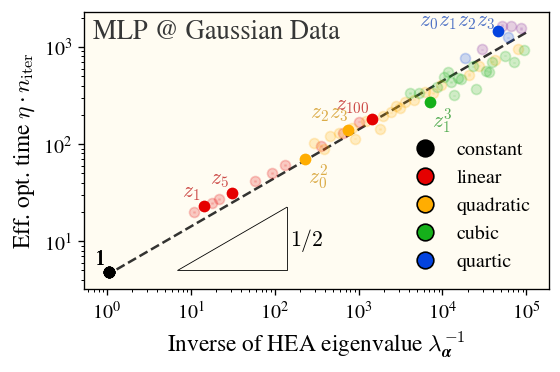

In [101]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
breakpoints_means = compat_low_width["breakpoints_means"]
breakpoints_std = compat_low_width["breakpoints_std"]

xaxis = ((hea_eigvals_low_width[locs_low_width.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_low_width[locs_low_width.long()].cpu(), breakpoints_means.cpu(), targets_low_width,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_low_width.min()) * 0.9
x_max = float(inv_eigs_low_width.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.65)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_low_width[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_low_width[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_low_width[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()


## bsz
unaffected

In [102]:
timekeys_low_bsz = compat_low_bsz["timekeys"]
targets_low_bsz = compat_low_bsz["targets"]
num_trials_low_bsz = compat_low_bsz["num_trials"]
monomials_low_bsz = compat_low_bsz["monomials"]
hea_eigvals_low_bsz = compat_low_bsz["hea_eigvals"]
locs_low_bsz = torch.zeros(len(targets_low_bsz))

for i, monomial in enumerate(targets_low_bsz):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_low_bsz):
        break
    # print(loc)
    loc = np.where(np.array(monomials_low_bsz) == monomial)[0][0]
    locs_low_bsz[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_low_bsz))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_low_bsz):
        break
    if monomial in monomials_low_bsz:
        loc = np.where(np.array(monomials_low_bsz) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc

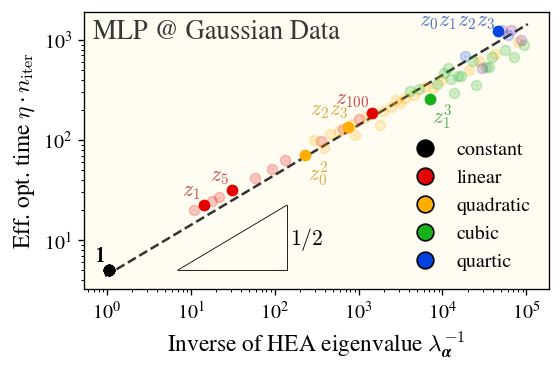

In [103]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
breakpoints_means = compat_low_bsz["breakpoints_means"]
breakpoints_std = compat_low_bsz["breakpoints_std"]

xaxis = ((hea_eigvals_low_bsz[locs_low_bsz.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_low_bsz[locs_low_bsz.long()].cpu(), breakpoints_means.cpu(), targets_low_bsz,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_low_bsz.min()) * 0.9
x_max = float(inv_eigs_low_bsz.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.65)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_low_bsz[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_low_bsz[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_low_bsz[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()


## data exponent

In [104]:
timekeys_low_data_exponent = compat_low_data_exponent["timekeys"]
targets_low_data_exponent = compat_low_data_exponent["targets"]
num_trials_low_data_exponent = compat_low_data_exponent["num_trials"]
monomials_low_data_exponent = compat_low_data_exponent["monomials"]
hea_eigvals_low_data_exponent = compat_low_data_exponent["hea_eigvals"]
locs_low_data_exponent = torch.zeros(len(targets_low_data_exponent))

for i, monomial in enumerate(targets_low_data_exponent):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_low_data_exponent):
        break
    # print(loc)
    loc = np.where(np.array(monomials_low_data_exponent) == monomial)[0][0]
    locs_low_data_exponent[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_low_data_exponent))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_low_data_exponent):
        break
    if monomial in monomials_low_data_exponent:
        loc = np.where(np.array(monomials_low_data_exponent) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc

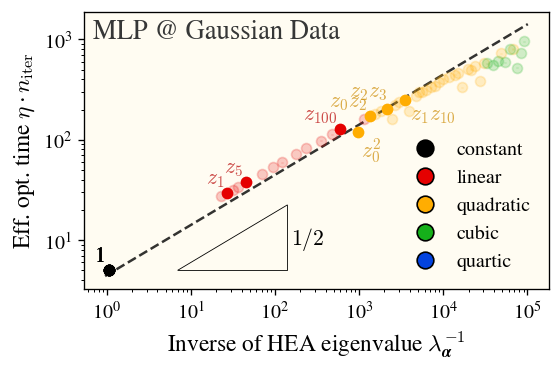

In [105]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
breakpoints_means = compat_low_data_exponent["breakpoints_means"]
breakpoints_std = compat_low_data_exponent["breakpoints_std"]

xaxis = ((hea_eigvals_low_data_exponent[locs_low_data_exponent.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_low_data_exponent[locs_low_data_exponent.long()].cpu(), breakpoints_means.cpu(), targets_low_data_exponent,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_low_data_exponent.min()) * 0.9
x_max = float(inv_eigs_low_data_exponent.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.65)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_low_data_exponent[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_low_data_exponent[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_low_data_exponent[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()


## NTK
slope->1; intercept??

In [106]:
timekeys_lazy = compat_lazy["timekeys"]
targets_lazy = compat_lazy["targets"]
num_trials_lazy = compat_lazy["num_trials"]
monomials_lazy = compat_lazy["monomials"]
hea_eigvals_lazy = compat_lazy["hea_eigvals"]
locs_lazy = torch.zeros(len(targets_lazy))

for i, monomial in enumerate(targets_lazy):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_lazy):
        break
    # print(loc)
    loc = np.where(np.array(monomials_lazy) == monomial)[0][0]
    locs_lazy[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_lazy))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_lazy):
        break
    if monomial in monomials_lazy:
        loc = np.where(np.array(monomials_lazy) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc

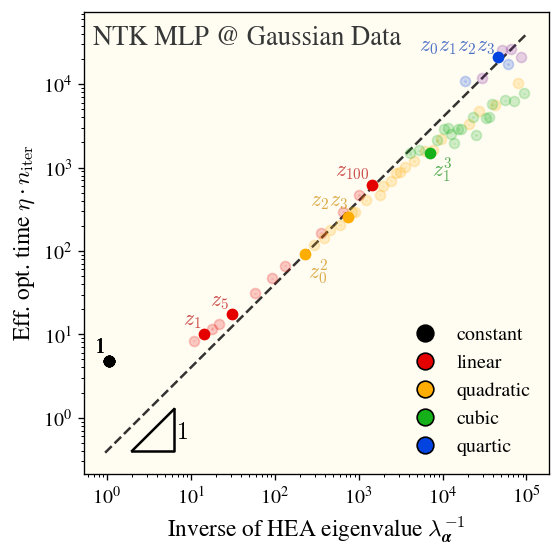

In [107]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
breakpoints_means = compat_lazy["breakpoints_means"]*1e4
breakpoints_std = compat_lazy["breakpoints_std"]*1e4

xaxis = ((hea_eigvals_lazy[locs_lazy.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_lazy[locs_lazy.long()].cpu(), breakpoints_means.cpu(), targets_lazy,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_lazy.min()) * 0.9
x_max = float(inv_eigs_lazy.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(-0.4)*(xaxis)**(1.0), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_lazy[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_lazy[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_lazy[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 2, .4
dlogx = 0.5        
dlogy = 1 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-')
ax.plot([x0, x1], [y0, y1], 'k-')  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1$', 
         va='center', ha='left', fontsize=14)

ax.text(0.02, 0.97, f"NTK MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()


## rich
seemingly unaffected

In [108]:
timekeys_ultra_rich = compat_ultra_rich["timekeys"]
targets_ultra_rich = compat_ultra_rich["targets"]
num_trials_ultra_rich = compat_ultra_rich["num_trials"]
monomials_ultra_rich = compat_ultra_rich["monomials"]
hea_eigvals_ultra_rich = compat_ultra_rich["hea_eigvals"]
locs_ultra_rich = torch.zeros(len(targets_ultra_rich))

for i, monomial in enumerate(targets_ultra_rich):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_ultra_rich):
        break
    # print(loc)
    loc = np.where(np.array(monomials_ultra_rich) == monomial)[0][0]
    locs_ultra_rich[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_ultra_rich))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_ultra_rich):
        break
    if monomial in monomials_ultra_rich:
        loc = np.where(np.array(monomials_ultra_rich) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc

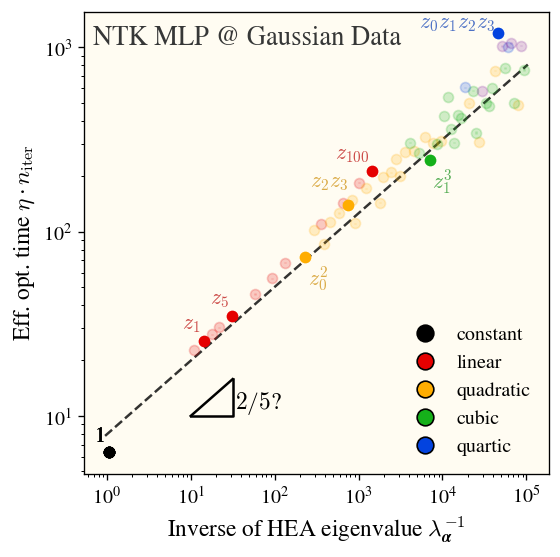

In [ ]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
breakpoints_means = compat_ultra_rich["breakpoints_means"]*1e-3
breakpoints_std = compat_ultra_rich["breakpoints_std"]*1e-3

xaxis = ((hea_eigvals_ultra_rich[locs_ultra_rich.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_ultra_rich[locs_ultra_rich.long()].cpu(), breakpoints_means.cpu(), targets_ultra_rich,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_ultra_rich.min()) * 0.9
x_max = float(inv_eigs_ultra_rich.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.9)*(xaxis)**(0.4), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_ultra_rich[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_ultra_rich[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_ultra_rich[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 10, 10
dlogx = 0.5        
dlogy = 0.4 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-')
ax.plot([x0, x1], [y0, y1], 'k-')  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$2/5$?', 
         va='center', ha='left', fontsize=14)

ax.text(0.02, 0.97, f"Ultra-Rich MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()


# CIFAR

In [178]:
timekeys_cifar = compat_cifar["timekeys"]
targets_cifar = compat_cifar["targets"]
num_trials_cifar = compat_cifar["num_trials"]
monomials_cifar = compat_cifar["monomials"]
hea_eigvals_cifar = compat_cifar["hea_eigvals"]
locs_cifar = torch.zeros(len(targets_cifar))

for i, monomial in enumerate(targets_cifar):
    monomial = Monomial.from_repr(monomial)
    # print(np.where(np.array(monomials) == monomial))
    if i >= len(targets_cifar):
        break
    # print(loc)
    loc = np.where(np.array(monomials_cifar) == monomial)[0][0]
    locs_cifar[i] = loc
    
tags = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1}, #{1:1,40:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]

noteable_targets = list(map(Monomial, tags))
t2 = list(map(Monomial.from_repr, targets_cifar))
noteable_locs = torch.zeros(len(noteable_targets))
noteable_y = torch.zeros(len(noteable_targets))

for i, monomial in enumerate(noteable_targets):
    if i >= len(targets_cifar):
        break
    if monomial in monomials_cifar:
        loc = np.where(np.array(monomials_cifar) == monomial)[0][0]
        noteable_locs[i] = loc
    if monomial in t2:
        loc = np.where(np.array(t2) == monomial)[0][0]
        noteable_y[i] = loc
        
# tags_cifar = [{}, {1:1}, {0:2}, {5:1}, {0:1,2:1}, {40:1},
#         {2:1, 3:1}, {1:3}, {150:1}, #{1:1,40:1},
#         {1:1, 60:1},  {0:2, 5:1}]

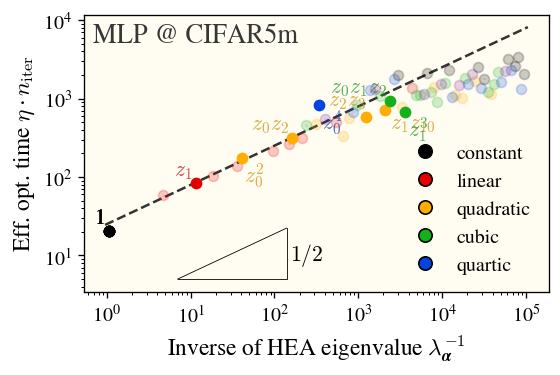

In [185]:
s = 6
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
breakpoints_means = compat_cifar["breakpoints_means"]
breakpoints_std = compat_cifar["breakpoints_std"]

xaxis = ((hea_eigvals_cifar[locs_cifar.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_cifar[locs_cifar.long()].cpu(), breakpoints_means.cpu(), targets_cifar,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_cifar.min()) * 0.9
x_max = float(inv_eigs_cifar.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(1.4)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
point_locs = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs, hea_eigvals_cifar[noteable_locs.long()]**(-1.), breakpoints_means[noteable_y.long()]):
    m = Monomial(monomials_cifar[idx.int().cpu().numpy()])
    if m in tags:
        color = colors[min(m.degree(), len(colors)-1)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags.index(monomials_cifar[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs[i] < 2 else "right",
                  "va": "bottom" if point_locs[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs[i] < 2 else -z,
            z if point_locs[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ CIFAR5m", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
plt.show()

# megaplot

## main fig

In [125]:
import matplotlib.transforms as mtransforms

def _dy_pixels_to_data(ax, x, y, dy_px):
    # Make sure transforms are current
    ax.figure.canvas.draw()
    p0x, p0y = ax.transData.transform((x, y))
    y1 = ax.transData.inverted().transform((p0x, p0y + dy_px))[1]
    return y1 - y  # data-space delta-y corresponding to dy_px

def triangle_y0_with_pixel_gap(ax, x0, A, m, gap_px):
    y_line = A * (x0**m)
    return y_line + _dy_pixels_to_data(ax, x0, y_line, gap_px)


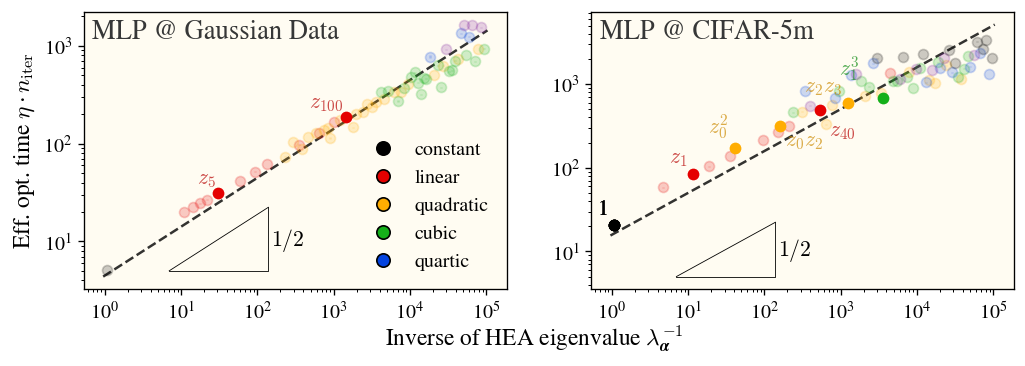

In [188]:
s = 6
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

ax = axes[0]

breakpoints_means = compat_base["breakpoints_means"]
breakpoints_std = compat_base["breakpoints_std"]

xaxis = ((hea_eigvals_base[locs_base.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_base[locs_base.long()].cpu(), breakpoints_means.cpu(), targets_base,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_base.min()) * 0.9
x_max = float(inv_eigs_base.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.65)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
tags_base = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]
noteable_targets_base = list(map(Monomial, tags_base))
t2_base = list(map(Monomial.from_repr, targets_base))
noteable_locs_base = torch.zeros(len(noteable_targets_base))
noteable_y_base = torch.zeros(len(noteable_targets_base))

for i, monomial in enumerate(noteable_targets_base):
    if i >= len(targets_base):
        break
    if monomial in monomials_base:
        loc = np.where(np.array(monomials_base) == monomial)[0][0]
        noteable_locs_base[i] = loc
    if monomial in t2_base:
        loc = np.where(np.array(t2_base) == monomial)[0][0]
        noteable_y_base[i] = loc

point_locs_base = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        0, 3]

for idx, xi, yi in zip(noteable_locs_base, hea_eigvals_base[noteable_locs_base.long()]**(-1.), breakpoints_means[noteable_y_base.long()]):
    m = Monomial(monomials_base[idx.int().cpu().numpy()])
    if m in tags_base:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags_base.index(monomials_base[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs_base[i] < 2 else "right",
                  "va": "bottom" if point_locs_base[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs_base[i] < 2 else -z,
            z if point_locs_base[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.28, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]-.14)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.04)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0], off[1]-.08)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
   
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,   
    )

# ax.set_xlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)
ax.set_ylabel("Eff. opt. time $\eta\cdot n_\mathrm{{iter}}$", fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')

# big_exponent_logticks(ax, axis='x', exp_scale=1.1, dx=1, dy=1)
ax = axes[1]

breakpoints_means = compat_cifar["breakpoints_means"]
breakpoints_std = compat_cifar["breakpoints_std"]

xaxis = ((hea_eigvals_cifar[locs_cifar.long()].cpu()))**(-1.)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_cifar[locs_cifar.long()].cpu(), breakpoints_means.cpu(), targets_cifar,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_cifar.min()) * 0.9
x_max = float(inv_eigs_cifar.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(1.2)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
tags_cifar = [{}, {1:1}, {0:2}, {5:1}, {0:1,2:1}, {40:1},
        {2:1, 3:1}, {1:3}, {150:1},
        {1:1, 60:1}, {0:2, 5:1}]
noteable_targets_cifar = list(map(Monomial, tags_cifar))
t2_cifar = list(map(Monomial.from_repr, targets_cifar))
noteable_locs_cifar = torch.zeros(len(noteable_targets_cifar))
noteable_y_cifar = torch.zeros(len(noteable_targets_cifar))

for i, monomial in enumerate(noteable_targets_cifar):
    if i >= len(targets_cifar):
        break
    if monomial in monomials_cifar:
        loc = np.where(np.array(monomials_cifar) == monomial)[0][0]
        noteable_locs_cifar[i] = loc
    if monomial in t2_cifar:
        loc = np.where(np.array(t2_cifar) == monomial)[0][0]
        noteable_y_cifar[i] = loc

point_locs_cifar = [3, 3, 3, 0,
        0, 0, 3, 3, 3,
        3, 0]

for idx, xi, yi in zip(noteable_locs_cifar, hea_eigvals_cifar[noteable_locs_cifar.long()]**(-1.), breakpoints_means[noteable_y_cifar.long()]):
    m = Monomial(monomials_cifar[idx.int().cpu().numpy()])
    if m in tags_cifar:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags_cifar.index(monomials_cifar[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs_cifar[i] < 2 else "right",
                  "va": "bottom" if point_locs_cifar[i] % 2 == 1 else "top"}
        z = 0.16
        off = (
            z if point_locs_cifar[i] < 2 else -z,
            z if point_locs_cifar[i] % 2 == 1 else -z
        )
        if m == Monomial({1:3}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (0.14, -0.14)
        elif m == Monomial({150:1}):
            kwargs["ha"] = "center"
            off = (off[0], off[1]+.24)
        elif m == Monomial({40:1}):
            off = (off[0]+.12, off[1]-.14)
        elif m == Monomial({0:2, 5:1}):
            off = (off[0]+.64, off[1]-0.08)
        elif m == Monomial({1:1, 60:1}):
            off = (off[0], off[1]+.1)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
        
#triangle 
x0, y0 = 7, 5
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"MLP @ CIFAR-5m", ha="left", va="top",
        transform=ax.transAxes, fontsize=16, color="xkcd:dark gray")

# color_handles = make_color_handles(colors, max_handle=3)
# all_handles = color_handles
# ax.legend(
#         handles=all_handles,
#         ncol=1,#2,
#         loc="lower right",
#         frameon=False,
#         columnspacing=1.2,
#         handletextpad=0.6,   
#     )

ax.set_xscale('log')
ax.set_yscale('log')
# plt.legend()
# xlbl = fig.supxlabel('Inverse of HEA eigenvalue $\lambda_{{\alpha}}^{{-1}}$', y=0.01, fontsize=14)
xlbl = fig.supxlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', y=0.01, fontsize=14)
xlbl.set_y(-0.07)
# fig.supylabel("Effective optimization time $\eta\cdot n_\mathrm{{iter}}$", fontsize=12)
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
# big_exponent_logticks(ax, axis='x', exp_scale=1.2, dx=1.2, dy=1.2)

plt.show()
# plt.savefig("fig5.pdf", bbox_inches='tight', dpi=300)


## across params

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


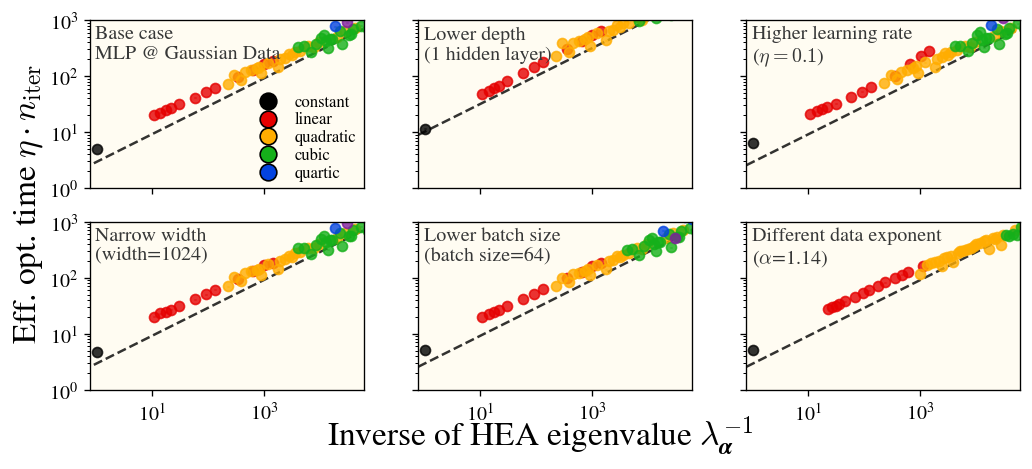

In [113]:
s = 6
fsize = 12
titlesize = 12
fig, axes = plt.subplots(2, 3, figsize=(10, 4), sharex=True, sharey=True)

ax = axes[0, 0]

breakpoints_means = compat_base["breakpoints_means"]
breakpoints_std = compat_base["breakpoints_std"]

xaxis = np.logspace(-2, 6, 20)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_base[locs_base.long()].cpu(), breakpoints_means.cpu(), targets_base,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.8, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
ax.plot(xaxis, 10**(0.46)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)# label=f"")

ax.text(0.02, 0.97, f"Base case\nMLP @ Gaussian Data", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6, 
        labelspacing=0.1,  
        fontsize=10,
        handleheight=0.4,
        borderaxespad = 0.05, 
    )

ax.set_xscale('log')
ax.set_yscale('log')

# ------------------------------------------------------------------------------------------------------------------------------

ax = axes[0, 1]

breakpoints_means = compat_low_depth["breakpoints_means"]
breakpoints_std = compat_low_depth["breakpoints_std"]

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_low_depth[locs_low_depth.long()].cpu(), breakpoints_means.cpu(), targets_low_depth,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.8, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
ax.plot(xaxis, 10**(1.0)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)# label=f"")

ax.text(0.02, 0.97, f"Lower depth\n(1 hidden layer)", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")


ax.set_xscale('log')
ax.set_yscale('log')

# ------------------------------------------------------------------------------------------------------------------------------

ax = axes[0, 2]

breakpoints_means = compat_high_lr["breakpoints_means"]
breakpoints_std = compat_high_lr["breakpoints_std"]

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_high_lr[locs_high_lr.long()].cpu(), breakpoints_means.cpu(), targets_high_lr,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.8, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
ax.plot(xaxis, 10**(0.46)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)# label=f"")     

ax.text(0.02, 0.97, f"Higher learning rate\n($\\eta=0.1$)", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")


ax.set_xscale('log')
ax.set_yscale('log')

# ------------------------------------------------------------------------------------------------------------------------------

ax = axes[1, 0]

s = 6
breakpoints_means = compat_low_width["breakpoints_means"]
breakpoints_std = compat_low_width["breakpoints_std"]

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_low_width[locs_low_width.long()].cpu(), breakpoints_means.cpu(), targets_low_width,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.8, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
ax.plot(xaxis, 10**(0.46)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)# label=f"")
        
ax.text(0.02, 0.97, f"Narrow width\n(width=1024)", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")

ax.set_xscale('log')
ax.set_yscale('log')

# ------------------------------------------------------------------------------------------------------------------------------

ax = axes[1, 1]

breakpoints_means = compat_low_bsz["breakpoints_means"]
breakpoints_std = compat_low_bsz["breakpoints_std"]

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_low_bsz[locs_low_bsz.long()].cpu(), breakpoints_means.cpu(), targets_low_bsz,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.8, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
ax.plot(xaxis, 10**(0.46)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)# label=f"")

ax.text(0.02, 0.97, f"Lower batch size\n(batch size=64)", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")

ax.set_xscale('log')
ax.set_yscale('log')

# ------------------------------------------------------------------------------------------------------------------------------

ax = axes[1, 2]

breakpoints_means = compat_low_data_exponent["breakpoints_means"]
breakpoints_std = compat_low_data_exponent["breakpoints_std"]

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_low_data_exponent[locs_low_data_exponent.long()].cpu(), breakpoints_means.cpu(), targets_low_data_exponent,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.8, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
ax.plot(xaxis, 10**(0.46)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)# label=f"")

#points
point_locs_alpha = [3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# for idx, xi, yi in zip(noteable_locs_alpha, hea_eigvals[noteable_locs_alpha.long()]**(-1.), breakpoints_means[noteable_y_alpha.long()]):
#     m = Monomial(monomials[idx.int().cpu().numpy()])
#     if m in tags_alpha:
#         color = colors[m.degree() % len(colors)]
#         ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
#         i = tags_alpha.index(monomials[idx.int().cpu().numpy()])
#         kwargs = {"ha": "left" if point_locs_alpha[i] < 2 else "right",
#                   "va": "bottom" if point_locs_alpha[i] % 2 == 1 else "top"}
#         z = 0.08
#         off = (
#             z if point_locs_alpha[i] < 2 else -z,
#             z if point_locs_alpha[i] % 2 == 1 else -z
#         )
#         ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=fsize,
#                     color=lighten(color, -0.2), alpha=0.7, **kwargs)
        

ax.text(0.02, 0.97, f"Different data exponent\n($\\alpha$=1.14)", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")


ax.set_xscale('log')
ax.set_yscale('log')

# ------------------------------------------------------------------------------------------------------------------------------

# xlbl = fig.supxlabel('Inverse of HEA eigenvalue $\\lambda_{{\\alpha}}^{{-1}}$', y=0.01, fontsize=20)
xlbl = fig.supxlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', y=0.01, fontsize=20)
ylbl = fig.supylabel("Eff. opt. time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=20)
xlbl.set_y(-0.03)
ylbl.set_x(0.06)

axes[0,0].set_xlim(1-.2, 6e4)
axes[0,0].set_ylim(1, 1e3)
# fig.supylabel("Effective optimization time $\\eta\\cdot n_\\mathrm{{iter}}$", fontsize=12)
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
# big_exponent_logticks(ax, axis='x', exp_scale=1.2, dx=1.2, dy=1.2)

# plt.show()
plt.savefig("hyperparam_sweep.pdf", bbox_inches='tight', dpi=300)

## across FL strength

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


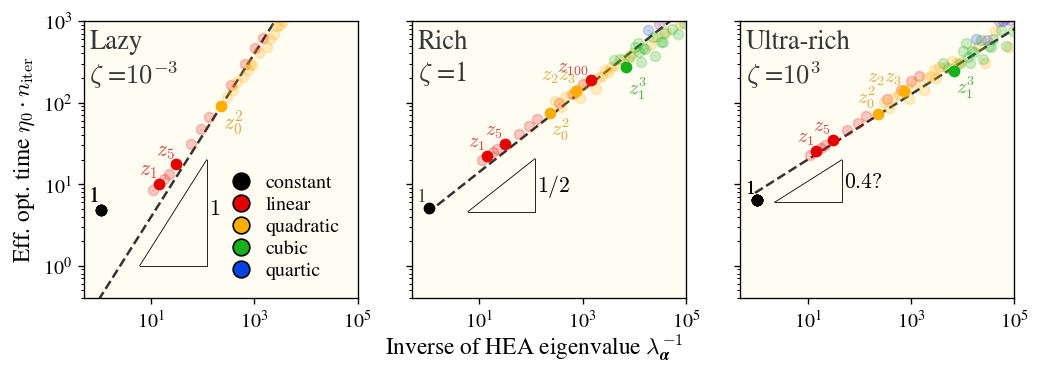

In [124]:
s = 6
fsize = 12
titlesize = 16
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

ax = axes[1]

breakpoints_means = compat_base["breakpoints_means"]
breakpoints_std = compat_base["breakpoints_std"]

xaxis = np.logspace(-2, 6, 20)

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_base[locs_base.long()].cpu(), breakpoints_means.cpu(), targets_base,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_base.min()) * 0.9
x_max = float(inv_eigs_base.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.65)*(xaxis)**(0.5), color='k', linestyle='--', alpha=0.8)

#points
tags_base = [{}, {1:1}, {5:1}, {100:1}, {204:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1},
        {1:3}, {0:1, 1:1, 2:1}, {3:1, 5:2},
        {0:4}, {0:1, 1:1, 2:1, 3:1}]
noteable_targets_base = list(map(Monomial, tags_base))
t2_base = list(map(Monomial.from_repr, targets_base))
noteable_locs_base = torch.zeros(len(noteable_targets_base))
noteable_y_base = torch.zeros(len(noteable_targets_base))

for i, monomial in enumerate(noteable_targets_base):
    if i >= len(targets_base):
        break
    if monomial in monomials_base:
        loc = np.where(np.array(monomials_base) == monomial)[0][0]
        noteable_locs_base[i] = loc
    if monomial in t2_base:
        loc = np.where(np.array(t2_base) == monomial)[0][0]
        noteable_y_base[i] = loc

point_locs_base = [3, 3, 3, 3,
        3, 0, 3, 3, 0,
        0, 3, 0,
        3, 3]

for idx, xi, yi in zip(noteable_locs_base, hea_eigvals_base[noteable_locs_base.long()]**(-1.), breakpoints_means[noteable_y_base.long()]):
    m = Monomial(monomials_base[idx.int().cpu().numpy()])
    if m in tags_base:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags_base.index(monomials_base[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs_base[i] < 2 else "right",
                  "va": "bottom" if point_locs_base[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs_base[i] < 2 else -z,
            z if point_locs_base[i] % 2 == 1 else -z
        )
        if m == Monomial({3:2, 5:1}):
            kwargs["ha"] = "center"
            off = (off[0]+0.2, off[1]+0.04)
        elif m == Monomial({3:1, 5:2}):
            kwargs["ha"] = "center"
            off = (off[0]-.08, off[1]-.28)
        elif m == Monomial({2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]+0.08, off[1]+0.08)
        elif m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.2)
        elif m == Monomial({1:3}):
            off = (off[0], off[1]-.12)
        elif m == Monomial({0:1, 1:1, 2:1, 3:1}):
            kwargs["ha"] = "right"
            off = (off[0]-.2, off[1]-.32)
        elif m == Monomial({0:4}):
            off = (off[0]+.12, off[1]+.2)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=fsize,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)

#triangle 
x0, y0 = 6, 4.6
dlogx = 1.3        
dlogy = 0.5 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$1/2$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.text(0.02, 0.97, f"Rich\n$\zeta$ =1", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")

ax = axes[0]

breakpoints_means = compat_lazy["breakpoints_means"]*1e4
breakpoints_std = compat_lazy["breakpoints_std"]*1e4

plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_lazy[locs_lazy.long()].cpu(), breakpoints_means.cpu(), targets_lazy,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_lazy.min()) * 0.9
x_max = float(inv_eigs_lazy.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(-0.4)*(xaxis)**(1.0), color='k', linestyle='--', alpha=0.8)

#points
tags_ntk = [{}, {1:1}, {5:1},
        {0:2}, {0:1,2:1}, {0:3}]
noteable_targets_ntk = list(map(Monomial, tags_ntk))
t2_ntk = list(map(Monomial.from_repr, targets_lazy))
noteable_locs_ntk = torch.zeros(len(noteable_targets_ntk))
noteable_y_ntk = torch.zeros(len(noteable_targets_ntk))

for i, monomial in enumerate(noteable_targets_ntk):
    if i >= len(targets_lazy):
        break
    if monomial in monomials_lazy:
        loc = np.where(np.array(monomials_lazy) == monomial)[0][0]
        noteable_locs_ntk[i] = loc
    if monomial in t2_ntk:
        loc = np.where(np.array(t2_ntk) == monomial)[0][0]
        noteable_y_ntk[i] = loc

point_locs_ntk = [3, 3, 3, 0, 3, 0]

for idx, xi, yi in zip(noteable_locs_ntk, hea_eigvals_lazy[noteable_locs_ntk.long()]**(-1.), breakpoints_means[noteable_y_ntk.long()]):
    m = Monomial(monomials_lazy[idx.int().cpu().numpy()])
    if m in tags_ntk:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags_ntk.index(monomials_lazy[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs_ntk[i] < 2 else "right",
                  "va": "bottom" if point_locs_ntk[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs_ntk[i] < 2 else -z,
            z if point_locs_ntk[i] % 2 == 1 else -z
        )
        if m == Monomial({0:1, 2:1}):
            off = (off[0]-.12, off[1]+0.08)
        elif m == Monomial({0:3}):
            off = (off[0]-.32, off[1]-.12)
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=13,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
        
#triangle 
x0, y0 = 6, 1
dlogx = 1.3        
dlogy = 1 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(.2), r'$1$', 
         va='center', ha='left', fontsize=13, fontweight="light")

color_handles = make_color_handles(colors, max_handle=4)
all_handles = color_handles
ax.legend(
        handles=all_handles,
        ncol=1,#2,
        loc="lower right",
        frameon=False,
        columnspacing=0.8,
        handletextpad=0.2,
        labelspacing=0.2,   
    )

ax.text(0.02, 0.97, f"Lazy\n$\zeta$ =$10^{{-3}}$", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")
ax.set_ylabel("Eff. opt. time $\eta_0\cdot n_\mathrm{{iter}}$", fontsize=14)

ax = axes[2]

breakpoints_means = compat_ultra_rich["breakpoints_means"]*1e-3
breakpoints_std = compat_ultra_rich["breakpoints_std"]*1e-3


plot_time_to_learn_eigenvalue_lightened_ax(ax, hea_eigvals_ultra_rich[locs_ultra_rich.long()].cpu(), breakpoints_means.cpu(), targets_ultra_rich,
                                scale='log', breakpoint="(error < 30% starting err)", alpha=0.2, errorbar=True, lightenamount=0,
                                yerr=breakpoints_std, colors=colors, s=s)
# solid line along emp points
x_min = float(inv_eigs_ultra_rich.min()) * 0.9
x_max = float(inv_eigs_ultra_rich.max()) * 1.1
xaxis = np.logspace(np.log10(x_min), np.log10(x_max), 30)
ax.plot(xaxis, 10**(0.9)*(xaxis)**(0.4), color='k', linestyle='--', alpha=0.8)


tags_rich = [{}, {1:1}, {5:1},
        {0:2}, {0:1,2:1}, {2:1, 3:1}, {1:1,10:1},
        {1:3}, {0:1, 1:1, 2:1},
        {0:4}]
noteable_targets_rich = list(map(Monomial, tags_rich))
t2_rich = list(map(Monomial.from_repr, targets_ultra_rich))
noteable_locs_rich = torch.zeros(len(noteable_targets_rich))
noteable_y_rich = torch.zeros(len(noteable_targets_rich))

for i, monomial in enumerate(noteable_targets_rich):
    if i >= len(targets_ultra_rich):
        break
    if monomial in monomials_ultra_rich:
        loc = np.where(np.array(monomials_ultra_rich) == monomial)[0][0]
        noteable_locs_rich[i] = loc
    if monomial in t2_rich:
        loc = np.where(np.array(t2_rich) == monomial)[0][0]
        noteable_y_rich[i] = loc

point_locs_rich = [3, 3, 3, 3, 0, 3, 0, 0, 3, 0,]

for idx, xi, yi in zip(noteable_locs_rich, hea_eigvals_ultra_rich[noteable_locs_rich.long()]**(-1.), breakpoints_means[noteable_y_rich.long()]):
    m = Monomial(monomials_ultra_rich[idx.int().cpu().numpy()])
    if m in tags_rich:
        color = colors[m.degree() % len(colors)]
        ax.scatter(xi, yi, color = color, alpha=1, zorder=10, s=s**2.)
        i = tags_rich.index(monomials_ultra_rich[idx.int().cpu().numpy()])
        kwargs = {"ha": "left" if point_locs_rich[i] < 2 else "right",
                  "va": "bottom" if point_locs_rich[i] % 2 == 1 else "top"}
        z = 0.08
        off = (
            z if point_locs_rich[i] < 2 else -z,
            z if point_locs_rich[i] % 2 == 1 else -z
        )
        if m == Monomial({1:1, 10:1}):
            kwargs["ha"] = "left"
            kwargs["va"] = "top"
            off = (off[0]+.07, off[1]-.2)
        elif m == Monomial({0:1, 2:1}):
            off = (off[0], off[1]-.32)
        elif m == Monomial({0:4}):
            off = (off[0]+.32, off[1])
        ax.annotate(str(m).replace('x', 'z'), (xi*(1+off[0]), yi*(1+off[1])), fontsize=fsize,
                    color=lighten(color, -0.2), alpha=0.7, **kwargs)
        
#triangle 
x0, y0 = 2.3, 6
dlogx = 1.3        
dlogy = 0.4 * dlogx 
x1 = x0 * 10**dlogx
y1 = y0 * 10**dlogy
dx = x1 - x0
dy = y1 - y0
x_coords = [x0, x1, x1]
y_coords = [y0, y0, y1]
ax.plot(x_coords, y_coords, 'k-', linewidth=0.5)
ax.plot([x0, x1], [y0, y1], 'k-', linewidth=0.5)  
ax.text(x0+dx*1.1, y0+dy*(np.log10(2)), r'$0.4?$', 
         va='center', ha='left', fontsize=13, fontweight="light")

ax.set_xscale('log')
ax.set_yscale('log')

ax.text(0.02, 0.97, f"Ultra-rich\n$\zeta$ =$10^{{3}}$", ha="left", va="top",
        transform=ax.transAxes, fontsize=titlesize, color="xkcd:dark gray")

# ax.set_xlabel('Inverse of HEA eigenvalue $\lambda_{{\alpha}}^{{-1}}$', y=0.01, fontsize=18)
xlbl = fig.supxlabel(r'Inverse of HEA eigenvalue $\lambda_{\boldsymbol{\alpha}}^{-1}$', fontsize=14)

# xlbl = fig.supxlabel('Inverse of HEA eigenvalue $\lambda_{{\boldsymbol{{\alpha}}}}^{{-1}}$', fontsize=14)
# fig.supylabel("Eff. opt. time $\eta\cdot n_\mathrm{{iter}}$", fontsize=24)
xlbl.set_y(-0.07)
# fig.supylabel("Effective optimization time $\eta\cdot n_\mathrm{{iter}}$", fontsize=12)
# ax.set_title(f"MLP @ Gaussian Data", fontsize=24)
# big_exponent_logticks(ax, axis='x', exp_scale=1.2, dx=1.2, dy=1.2)
axes[0].set_xlim(1-.5, 1e5)
axes[0].set_ylim(1-.6, 1e3)

# plt.show()
plt.savefig("richness_sweep.pdf", bbox_inches='tight', dpi=300)
